# 03 — Análise exploratória da série semanal

Objetivo: avaliar comportamento temporal, cobertura, variações atípicas e autocorrelação do Diesel S10/RS antes de criar features ou treinar modelos. A última semana parcial permanece documentada, mas não entra na série de modelagem.

In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.eda import (
    autocorrelation_table, chronological_split, load_weekly_series, prepare_eda
)

## 1. Carregar e preparar

In [14]:
DATA_DIR = PROJECT_ROOT / 'processed' / 'anp' / 'revenda'
weekly, quality = load_weekly_series(
    DATA_DIR / 'diesel_s10_rs_semanal.csv',
    DATA_DIR / 'diesel_s10_rs_qualidade.json',
)
eda, summary = prepare_eda(weekly, quality)
pd.Series(summary, name='valor').to_frame()

,valor
primeira_semana,2024-01-07
ultima_semana,2026-07-05
ultima_coleta,2026-06-30
semanas_totais,131
semanas_para_modelagem,130
semanas_incompletas_no_fim,1
semanas_sem_dados,0
limite_inferior_outlier_pct,-1.01517
limite_superior_outlier_pct,0.883214
variacoes_atipicas,9


In [15]:
assert summary['semanas_sem_dados'] == 0, 'Existem lacunas que precisam ser investigadas.'
display(eda.loc[~eda['utilizar_modelagem'], [
    'semana_fim', 'preco_medio', 'numero_postos',
    'semana_sem_dados', 'semana_completa_na_fonte'
]])

,semana_fim,preco_medio,numero_postos,semana_sem_dados,semana_completa_na_fonte
130,2026-07-05,6.819051,158,False,False


## 2. Evolução do preço

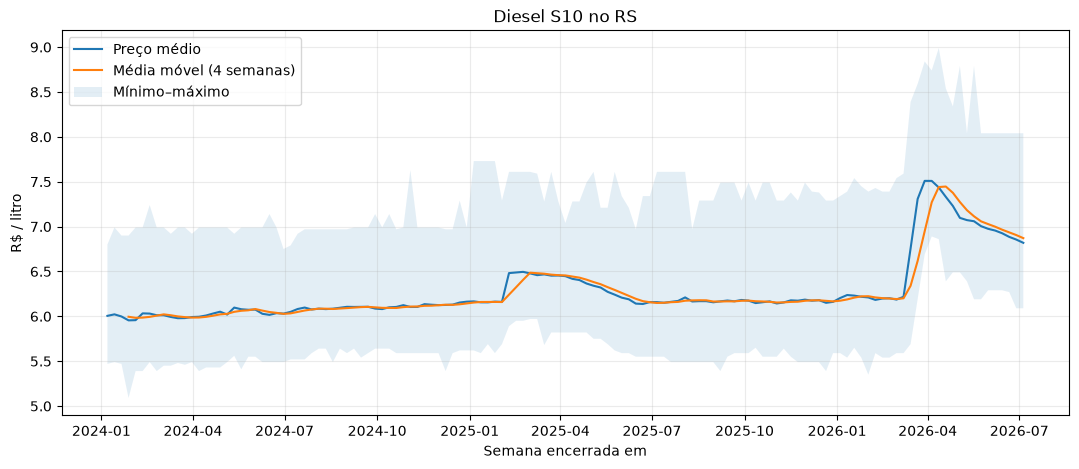

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(eda['semana_fim'], eda['preco_medio'], label='Preço médio', linewidth=1.5)
ax.plot(eda['semana_fim'], eda['media_movel_4'], label='Média móvel (4 semanas)')
ax.fill_between(eda['semana_fim'], eda['preco_minimo'], eda['preco_maximo'], alpha=0.12, label='Mínimo–máximo')
ax.set(title='Diesel S10 no RS', xlabel='Semana encerrada em', ylabel='R$ / litro')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 3. Cobertura da pesquisa

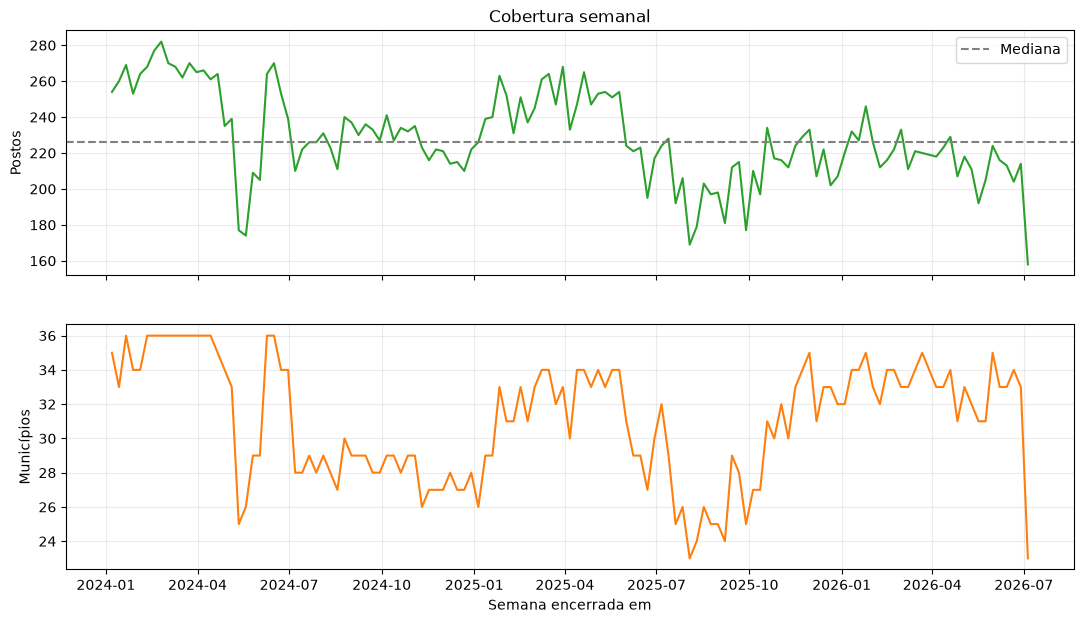

,numero_postos,numero_municipios,preco_medio
count,131.000000,131.000000,131.000000
mean,228.381679,31.068702,6.279860
std,24.595015,3.435540,0.349968
min,158.000000,23.000000,5.955099
25%,213.500000,28.500000,6.090859
50%,226.000000,32.000000,6.161401
75%,246.500000,34.000000,6.239553
max,282.000000,36.000000,7.509315


In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(eda['semana_fim'], eda['numero_postos'], color='tab:green')
axes[0].axhline(eda['numero_postos'].median(), linestyle='--', color='gray', label='Mediana')
axes[0].set(ylabel='Postos', title='Cobertura semanal')
axes[0].legend()
axes[1].plot(eda['semana_fim'], eda['numero_municipios'], color='tab:orange')
axes[1].set(xlabel='Semana encerrada em', ylabel='Municípios')
for ax in axes: ax.grid(alpha=0.25)
plt.show()

eda[['numero_postos', 'numero_municipios', 'preco_medio']].describe()

## 4. Variações semanais e pontos atípicos

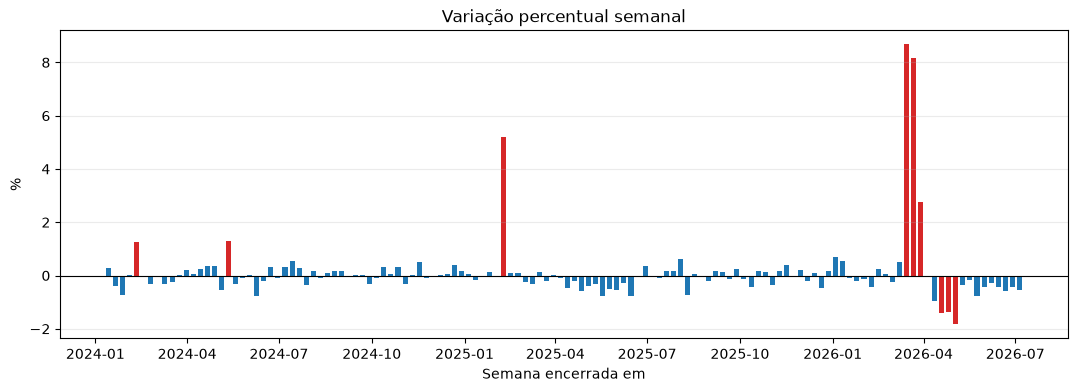

,semana_fim,preco_medio,variacao_pct,numero_postos,numero_municipios
5,2024-02-11,6.032948,1.270941,268,36
18,2024-05-12,6.097458,1.289488,177,25
57,2025-02-09,6.481732,5.204617,231,31
114,2026-03-15,6.756968,8.672677,221,34
115,2026-03-22,7.307500,8.147614,220,35
116,2026-03-29,7.509315,2.761753,219,34
119,2026-04-19,7.331048,-1.412117,229,34
120,2026-04-26,7.230000,-1.378357,207,31
121,2026-05-03,7.097018,-1.839304,218,33


In [19]:
colors = eda['variacao_atipica_iqr'].map({
    True: 'tab:red',
    False: 'tab:blue'
})

fig, ax = plt.subplots(figsize=(13, 4))

ax.bar(
    eda['semana_fim'],
    eda['variacao_pct'],
    width=5,
    color=colors
)

ax.axhline(0, color='black', linewidth=0.8)

ax.set(
    title='Variação percentual semanal',
    xlabel='Semana encerrada em',
    ylabel='%'
)

ax.grid(axis='y', alpha=0.25)

plt.show()

eda.loc[
    eda['variacao_atipica_iqr'] & eda['utilizar_modelagem'],
    ['semana_fim', 'preco_medio', 'variacao_pct', 'numero_postos', 'numero_municipios']
]

Pontos atípicos não são removidos automaticamente: podem representar reajustes reais, mudanças regulatórias ou choques de mercado.

## 5. Autocorrelação

,lag_semanas,autocorr_preco,autocorr_variacao
0,1,0.972906,0.556240
1,2,0.914560,0.158271
2,3,0.845603,-0.048222
3,4,0.776901,-0.134254
4,5,0.713200,-0.161350
5,6,0.656565,-0.168633
6,7,0.607437,-0.108446
7,8,0.562352,-0.047137
8,9,0.517633,-0.043050
9,10,0.472539,-0.017698


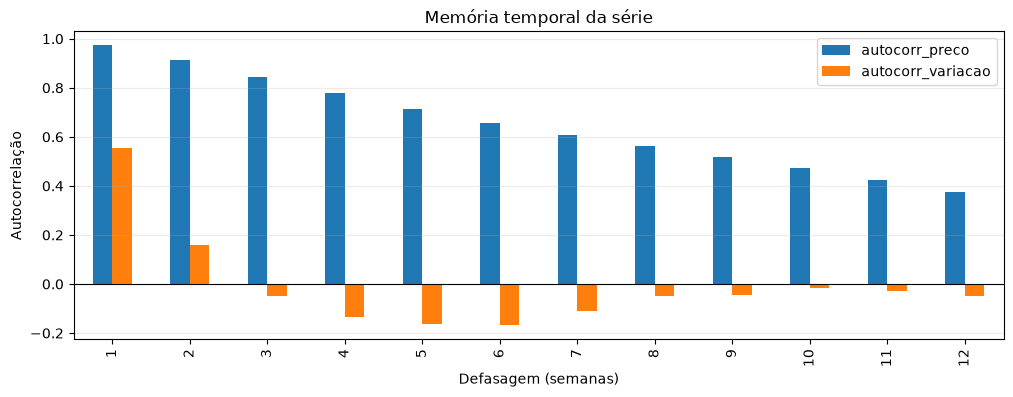

In [8]:
acf = autocorrelation_table(eda, max_lag=12)
display(acf)

ax = acf.plot(
    x='lag_semanas', y=['autocorr_preco', 'autocorr_variacao'],
    kind='bar', figsize=(12, 4)
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set(xlabel='Defasagem (semanas)', ylabel='Autocorrelação', title='Memória temporal da série')
ax.grid(axis='y', alpha=0.25)
plt.show()

Autocorrelação alta no nível de preço é esperada. Para avaliar previsibilidade de movimentos, observe principalmente a autocorrelação da variação.

## 6. Corte cronológico inicial

In [9]:
train, test = chronological_split(eda, test_weeks=26)
split_summary = pd.DataFrame({
    'conjunto': ['treino', 'teste'],
    'inicio': [train['semana_fim'].min(), test['semana_fim'].min()],
    'fim': [train['semana_fim'].max(), test['semana_fim'].max()],
    'semanas': [len(train), len(test)],
})
split_summary

,conjunto,inicio,fim,semanas
0,treino,2024-01-07,2025-12-28,104
1,teste,2026-01-04,2026-06-28,26


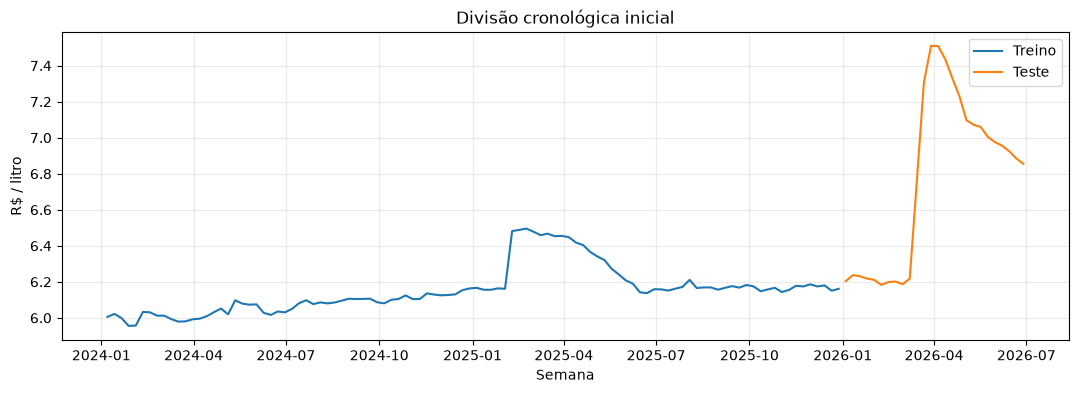

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train['semana_fim'], train['preco_medio'], label='Treino')
ax.plot(test['semana_fim'], test['preco_medio'], label='Teste', color='tab:orange')
ax.set(title='Divisão cronológica inicial', xlabel='Semana', ylabel='R$ / litro')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Decisão para a próxima etapa

O holdout final de 26 semanas serve para uma primeira comparação. Na avaliação definitiva será usado walk-forward validation. O próximo notebook deve criar lags sem vazamento e comparar o baseline ingênuo `preço(t+1) = preço(t)`.